Cell 1: Imports

In [1]:
import os
import cv2
import torch
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score
)

from sklearn.utils.class_weight import compute_class_weight

from PIL import Image

import torch.nn as nn
from torch.utils.data import (
    Dataset,
    DataLoader,
    WeightedRandomSampler
)

from torchvision import transforms, models

Cell 2: Config

In [2]:
PATCH_DATASET_DIR = Path("patch_dataset")

PATCH_CSV_PATH = PATCH_DATASET_DIR / "patch_index.csv"

MODEL_SAVE_PATH = "best_patch_model.pth"

IMAGE_SIZE = 128

BATCH_SIZE = 32

EPOCHS = 5

LEARNING_RATE = 1e-4

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cuda


In [3]:
print(PATCH_CSV_PATH.exists())

True


Cell 3: Load patch dataset

In [4]:
patch_df = pd.read_csv(PATCH_CSV_PATH)

print("Total patches:", len(patch_df))

patch_df.head()

Total patches: 106552


,patch_path,source_image_path,annotation_path,split,label,center_x,center_y,patch_type
0,patch_dataset\images\train_neg_0_0.png,D:\Judy Uni\archive\PVDN\night\train\images\S0...,D:\Judy Uni\archive\PVDN\night\train\labels\ke...,train,0,910,633,negative_road
1,patch_dataset\images\train_neg_1_0.png,D:\Judy Uni\archive\PVDN\night\train\images\S0...,D:\Judy Uni\archive\PVDN\night\train\labels\ke...,train,0,281,716,negative_road
2,patch_dataset\images\train_neg_2_0.png,D:\Judy Uni\archive\PVDN\night\train\images\S0...,D:\Judy Uni\archive\PVDN\night\train\labels\ke...,train,0,506,690,negative_road
3,patch_dataset\images\train_neg_3_0.png,D:\Judy Uni\archive\PVDN\night\train\images\S0...,D:\Judy Uni\archive\PVDN\night\train\labels\ke...,train,0,398,628,negative_road
4,patch_dataset\images\train_neg_4_0.png,D:\Judy Uni\archive\PVDN\night\train\images\S0...,D:\Judy Uni\archive\PVDN\night\train\labels\ke...,train,0,948,620,negative_road


Cell 4: Split data

In [5]:
train_df = patch_df[
    patch_df["split"] == "train"
].reset_index(drop=True)

val_df = patch_df[
    patch_df["split"] == "val"
].reset_index(drop=True)

test_df = patch_df[
    patch_df["split"] == "test"
].reset_index(drop=True)

print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

Train: 79998
Val: 13296
Test: 13258


Cell 5: Check balance

In [6]:
print(train_df["label"].value_counts())

print()

print(
    train_df["label"]
    .value_counts(normalize=True)
)

label
0    48501
1    31497
Name: count, dtype: int64

label
0    0.606278
1    0.393722
Name: proportion, dtype: float64


Cell 6: Transforms

In [7]:
train_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(3),

    transforms.ColorJitter(
        brightness=0.08,
        contrast=0.08
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

val_transform = transforms.Compose([

    transforms.Resize(
        (IMAGE_SIZE, IMAGE_SIZE)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

Cell 7: Dataset Class

In [8]:
class PatchDataset(Dataset):

    def __init__(self, df, transform=None):

        self.df = df.reset_index(drop=True)

        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        image = cv2.imread(
            row["patch_path"],
            cv2.IMREAD_GRAYSCALE
        )

        image = cv2.cvtColor(
            image,
            cv2.COLOR_GRAY2RGB
        )

        image = Image.fromarray(image)

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(
            row["label"],
            dtype=torch.float32
        )

        return image, label

Cell 8: Create datasets

In [9]:
train_dataset = PatchDataset(
    train_df,
    transform=train_transform
)

val_dataset = PatchDataset(
    val_df,
    transform=val_transform
)

test_dataset = PatchDataset(
    test_df,
    transform=val_transform
)

print("Datasets ready.")

Datasets ready.


Cell 9: Visualize patches

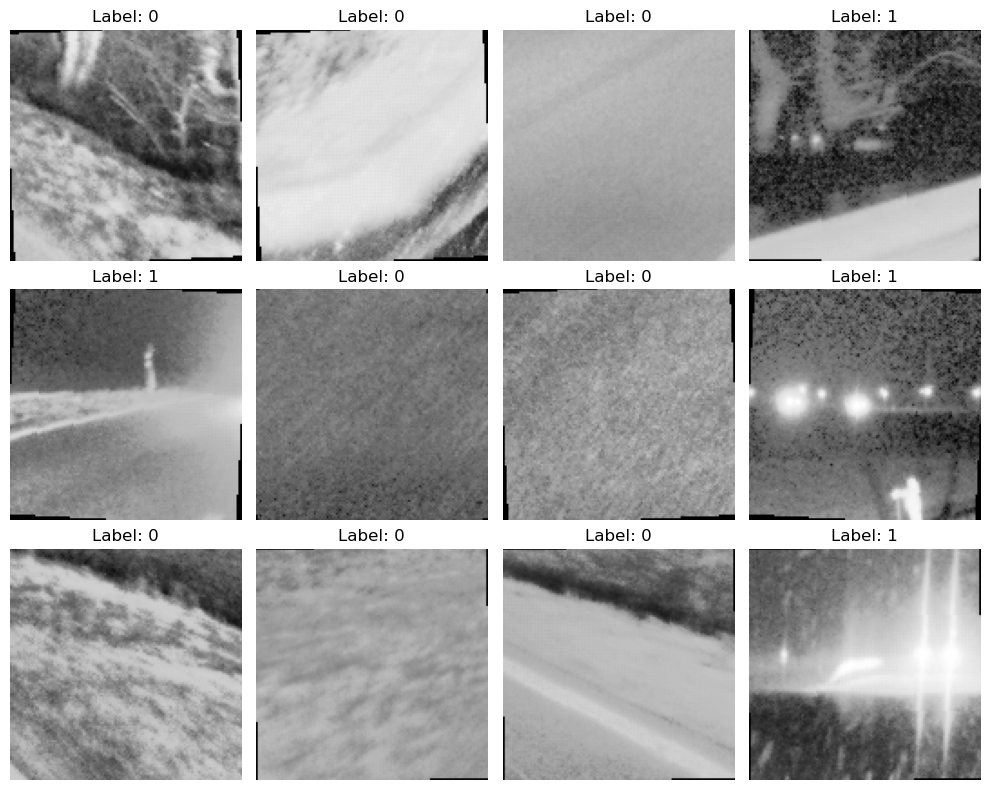

In [10]:
fig, axes = plt.subplots(3, 4, figsize=(10,8))

for ax in axes.flatten():

    idx = random.randint(
        0,
        len(train_dataset)-1
    )

    image, label = train_dataset[idx]

    image = image.permute(1,2,0).numpy()

    image = (image * 0.5) + 0.5

    ax.imshow(image)

    ax.set_title(
        f"Label: {int(label.item())}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

Cell 10: Weighted sampler

In [11]:
labels = train_df["label"].values

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(labels),
    y=labels
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float
)

sample_weights = class_weights[labels]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

print("Sampler ready.")

Sampler ready.


Cell 11: Dataloaders

In [12]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("Loaders ready.")

Loaders ready.


Cell 12: Model

In [13]:
model = models.efficientnet_b0(
    weights="DEFAULT"
)

in_features = model.classifier[1].in_features

model.classifier[1] = nn.Linear(
    in_features,
    1
)

model = model.to(device)

print("Model ready.")

Model ready.


Cell 13: Loss + Optimizer

In [19]:
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE
)

scaler = torch.amp.GradScaler("cuda")
print("Training setup ready.")

Training setup ready.


Cell 14: Train function

In [20]:
def train_one_epoch(model, loader):

    model.train()

    running_loss = 0

    preds_all = []
    labels_all = []

    loop = tqdm(loader)

    for images, labels in loop:

        images = images.to(device)

        labels = labels.to(device)

        labels = labels.unsqueeze(1)

        optimizer.zero_grad()

        with torch.amp.autocast(device_type="cuda"):

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item()

        probs = torch.sigmoid(outputs)

        preds = (probs > 0.5).float()

        preds_all.extend(
            preds.cpu().numpy().flatten()
        )

        labels_all.extend(
            labels.cpu().numpy().flatten()
        )

        loop.set_postfix(
            loss=loss.item()
        )

    loss_avg = running_loss / len(loader)

    acc = accuracy_score(
        labels_all,
        preds_all
    )

    recall = recall_score(
        labels_all,
        preds_all
    )

    return loss_avg, acc, recall

Cell 15: Validation function

In [21]:
def validate(model, loader):

    model.eval()

    running_loss = 0

    preds_all = []
    labels_all = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)

            labels = labels.to(device)

            labels = labels.unsqueeze(1)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            running_loss += loss.item()

            probs = torch.sigmoid(outputs)

            preds = (probs > 0.5).float()

            preds_all.extend(
                preds.cpu().numpy().flatten()
            )

            labels_all.extend(
                labels.cpu().numpy().flatten()
            )

    loss_avg = running_loss / len(loader)

    acc = accuracy_score(
        labels_all,
        preds_all
    )

    recall = recall_score(
        labels_all,
        preds_all
    )

    return loss_avg, acc, recall

Cell 16: Training loop

In [22]:
best_recall = 0

train_losses = []
val_losses = []

train_accs = []
val_accs = []

train_recalls = []
val_recalls = []

for epoch in range(EPOCHS):

    print("\n" + "="*60)
    print(f"EPOCH {epoch+1}/{EPOCHS}")
    print("="*60)

    train_loss, train_acc, train_recall = train_one_epoch(
        model,
        train_loader
    )

    val_loss, val_acc, val_recall = validate(
        model,
        val_loader
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    train_recalls.append(train_recall)
    val_recalls.append(val_recall)

    print(f"Train Loss   : {train_loss:.4f}")
    print(f"Train Acc    : {train_acc:.4f}")
    print(f"Train Recall : {train_recall:.4f}")

    print(f"Val Loss     : {val_loss:.4f}")
    print(f"Val Acc      : {val_acc:.4f}")
    print(f"Val Recall   : {val_recall:.4f}")

    if val_recall > best_recall:

        best_recall = val_recall

        torch.save(
            model.state_dict(),
            MODEL_SAVE_PATH
        )

        print("Best model saved.")


EPOCH 1/5


100%|██████████| 2500/2500 [22:15<00:00,  1.87it/s, loss=0.0132]  


Train Loss   : 0.0426
Train Acc    : 0.9868
Train Recall : 0.9866
Val Loss     : 0.0578
Val Acc      : 0.9826
Val Recall   : 0.9634
Best model saved.

EPOCH 2/5


100%|██████████| 2500/2500 [15:20<00:00,  2.72it/s, loss=0.00282] 


Train Loss   : 0.0136
Train Acc    : 0.9958
Train Recall : 0.9958
Val Loss     : 0.0678
Val Acc      : 0.9826
Val Recall   : 0.9595

EPOCH 3/5


100%|██████████| 2500/2500 [11:54<00:00,  3.50it/s, loss=0.000324]


Train Loss   : 0.0088
Train Acc    : 0.9970
Train Recall : 0.9969
Val Loss     : 0.0964
Val Acc      : 0.9804
Val Recall   : 0.9540

EPOCH 4/5


  3%|▎         | 68/2500 [00:10<06:24,  6.32it/s, loss=0.00197] 


KeyboardInterrupt: 

Cell 17: Plot Metrics

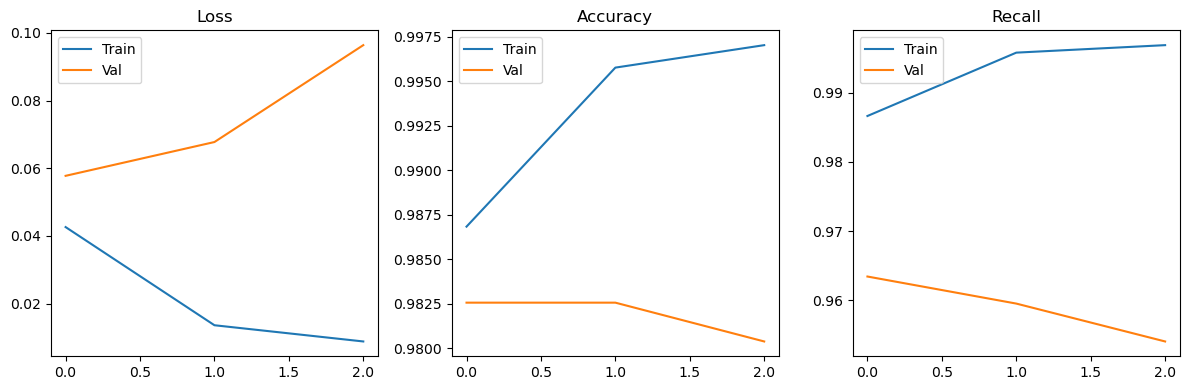

In [23]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Val")
plt.title("Loss")
plt.legend()

plt.subplot(1,3,2)
plt.plot(train_accs, label="Train")
plt.plot(val_accs, label="Val")
plt.title("Accuracy")
plt.legend()

plt.subplot(1,3,3)
plt.plot(train_recalls, label="Train")
plt.plot(val_recalls, label="Val")
plt.title("Recall")
plt.legend()

plt.tight_layout()
plt.show()

Cell 18: Load best model

In [24]:
model.load_state_dict(
    torch.load(MODEL_SAVE_PATH)
)

model.eval()

print("Best model loaded.")

Best model loaded.


C:\Users\Legion\AppData\Local\Temp\ipykernel_21432\1321037349.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(MODEL_SAVE_PATH)


Cell 19: Test evaluation

In [25]:
preds_all = []
labels_all = []

with torch.no_grad():

    for images, labels in tqdm(test_loader):

        images = images.to(device)

        outputs = model(images)

        probs = torch.sigmoid(outputs)

        preds = (probs > 0.5).float()

        preds_all.extend(
            preds.cpu().numpy().flatten()
        )

        labels_all.extend(
            labels.numpy().flatten()
        )

acc = accuracy_score(
    labels_all,
    preds_all
)

recall = recall_score(
    labels_all,
    preds_all
)

precision = precision_score(
    labels_all,
    preds_all
)

f1 = f1_score(
    labels_all,
    preds_all
)

print("\nFINAL TEST RESULTS")
print("="*50)

print(f"Accuracy : {acc:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1 Score : {f1:.4f}")

100%|██████████| 415/415 [02:11<00:00,  3.17it/s]


FINAL TEST RESULTS
Accuracy : 0.9919
Recall   : 0.9887
Precision: 0.9908
F1 Score : 0.9897


Cell 20: Confusion matrix

In [26]:
cm = confusion_matrix(
    labels_all,
    preds_all
)

print(cm)

[[7985   48]
 [  59 5166]]


Cell 21: Classification report

In [28]:
print(
    classification_report(
        labels_all,
        preds_all
    )
)

              precision    recall  f1-score   support

         0.0       0.99      0.99      0.99      8033
         1.0       0.99      0.99      0.99      5225

    accuracy                           0.99     13258
   macro avg       0.99      0.99      0.99     13258
weighted avg       0.99      0.99      0.99     13258

